In [164]:
import os
import re
import csv
import numpy as np
import pandas as pd
import mendeleev as md
from math import gcd
from ase.io import read
import matplotlib.pyplot as plt

# Show float values with 2 decimal places when displaying DataFrames.
pd.options.display.float_format = '{:.2f}'.format

# Ensure wide DataFrames print all columns (no truncation).
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 20000)
pd.set_option('display.expand_frame_repr', True)

root = '/Users/jiuy97/Desktop/3_RuO2/7_prediction'
# root = '/Users/hailey/Desktop/3_RuO2/6_ICOHP/4_slab_M-RuO2'
# oxygen_potential = -4.658724749999999 # 300K
oxygen_potential = -4.658724749999999+0.27-0.73 # 700K
# oxygen_potential = -4.658724749999999+0.27-0.85 # 800K
figsize = (8, 6)
dpi = 300

In [165]:
element_indices = list(range(21, 31)) + list(range(39, 49)) + [57] + list(range(72, 81))
elements = [md.element(i).symbol for i in element_indices]
data = pd.DataFrame(index=elements)

In [166]:
# os: oxidation state
for dir in ['1_MxOy', '2_MO2', '3_M-RuO2']:
    oxide_type = dir.split('_')[1]
    for i in element_indices:
        element = md.element(i).symbol
        path = os.path.join(root, '1_bulk_opt', dir, f'{i}_{element}')
        energy_file = os.path.join(path, 'final_with_calculator.json')
        if os.path.exists(energy_file):
            atoms = read(energy_file)
            n_atoms = len(atoms)
            n_oxygens = sum(atom.symbol == 'O' for atom in atoms)
            n_metals = n_atoms - n_oxygens
            oxidation_state = 2 * n_oxygens / n_metals
            energy = atoms.get_potential_energy() / n_metals
            data.loc[element, f'{oxide_type}_e'] = energy
            if oxide_type == 'MxOy':
                common_divisor = gcd(n_metals, n_oxygens)
                m_ratio = n_metals // common_divisor
                o_ratio = n_oxygens // common_divisor
                data.loc[element, f'{oxide_type}_x'] = m_ratio
                data.loc[element, f'{oxide_type}_y'] = o_ratio
                data.loc[element, f'{oxide_type}_os'] = oxidation_state

# de: doping energy
# fe: formation energy
data['M-RuO2_de'] = data['M-RuO2_e'] - 7/8*data['MO2_e']['Ru'] - 1/8*data['MO2_e']
data['M-RuO2_fe'] = data['M-RuO2_e'] - 7/8*data['MO2_e']['Ru'] - 1/8*data['MxOy_e'] - (2-data['MxOy_y']/data['MxOy_x'])/8*oxygen_potential
# data['MxOy_fe'] = data['MxOy_e'] - data['MO2_e'] - (2-data['MxOy_y']/data['MxOy_x'])*oxygen_potential
data.drop(columns=['MO2_e', 'MxOy_e', 'M-RuO2_e'], inplace=True)
data.loc['Nb', 'MxOy_x'] = 2
data.loc['Nb', 'MxOy_y'] = 5
data


,MxOy_x,MxOy_y,MxOy_os,M-RuO2_de,M-RuO2_fe
Sc,2.00,3.00,3.00,-0.14,0.05
Ti,1.00,2.00,4.00,0.04,0.03
V,2.00,3.00,3.00,0.01,-0.05
Cr,2.00,3.00,3.00,-0.04,0.01
Mn,3.00,4.00,2.67,0.15,0.15
Fe,2.00,3.00,3.00,-0.09,-0.02
Co,3.00,4.00,2.67,0.00,0.05
Ni,1.00,1.00,2.00,-0.22,0.00
Cu,1.00,1.00,2.00,-0.24,0.03
Zn,1.00,1.00,2.00,-0.25,0.05


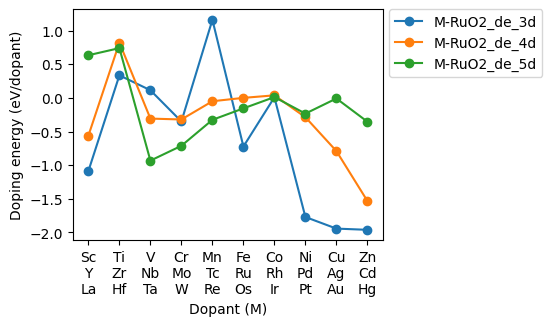

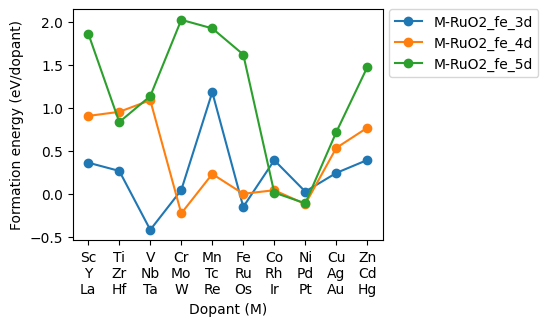

In [167]:

colors = ['tab:blue', 'tab:orange', 'tab:green']

n = len(data)
chunk = 10
slices = [(0, chunk), (chunk, 2 * chunk), (2 * chunk, n)]
row_suffix = ['3d', '4d', '5d']
x = np.arange(1, chunk + 1)
xtick_labels = []
for i in range(chunk):
    xtick_labels.append(
        '\n'.join(
            str(data.index[lo + i])
            for lo, hi in slices
            if lo + i < min(hi, n)
        )
    )

for col in ['M-RuO2_de', 'M-RuO2_fe']:
    plt.figure(figsize=(4,3))

    for si, (lo, hi) in enumerate(slices):
        if lo >= n:
            break
        hi = min(hi, n)
        y = (data[col].iloc[lo:hi]*8).to_numpy() # per dopant
        plt.plot(
            x[: len(y)],
            y,
            marker='o',
            linestyle='-',
            label=f'{col}_{row_suffix[si]}',
            color=colors[si % len(colors)],
        )

    plt.xlim(0.5, chunk + 0.5)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.xticks(x, xtick_labels)

    plt.xlabel('Dopant (M)')
    if col == 'M-RuO2_de':
        plt.ylabel('Doping energy (eV/dopant)')
        plt.savefig(f'{root}/figures/bulk_doping_energy.png', dpi=dpi, transparent=True, bbox_inches='tight')
    else:
        plt.ylabel('Formation energy (eV/dopant)')
        plt.savefig(f'{root}/figures/bulk_formation_energy.png', dpi=dpi, transparent=True, bbox_inches='tight')

    plt.show()
    plt.close()

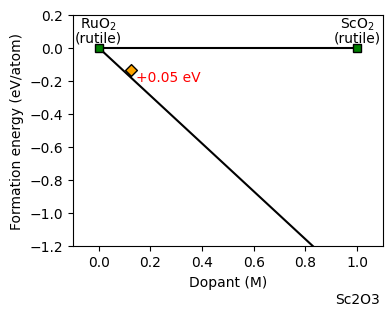

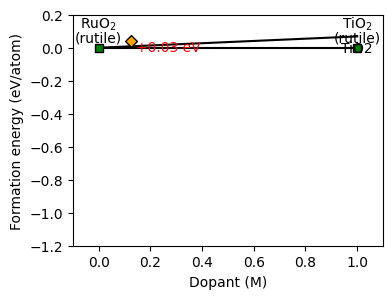

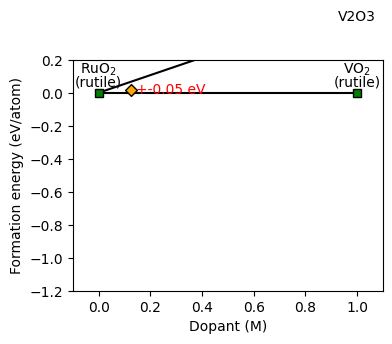

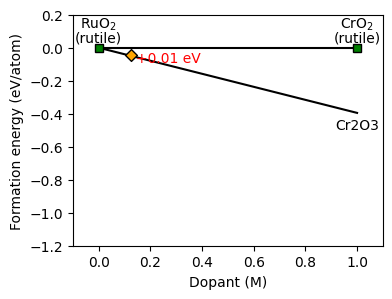

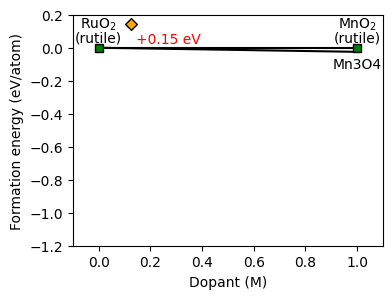

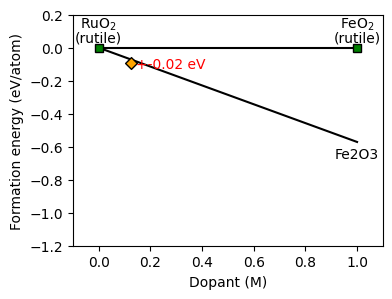

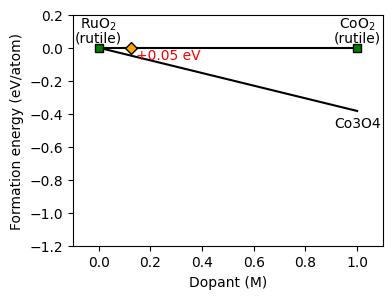

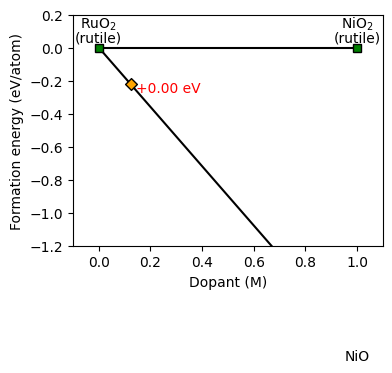

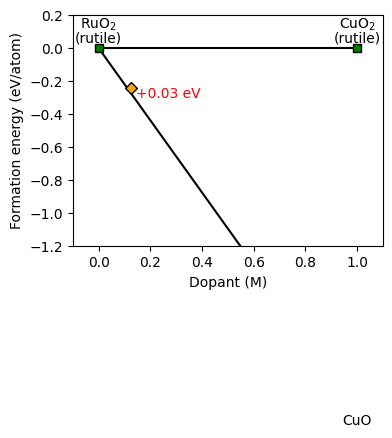

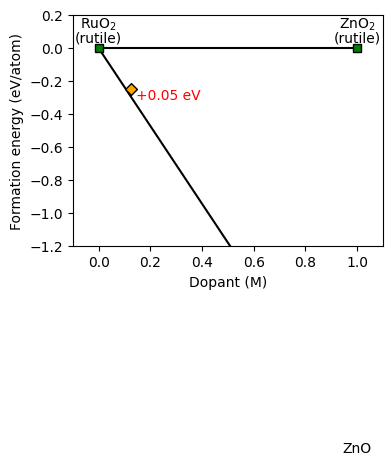

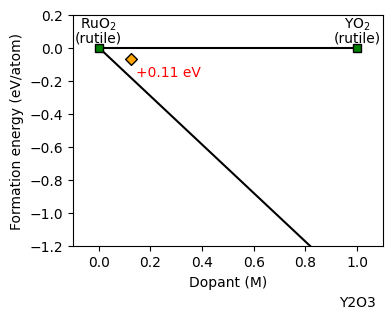

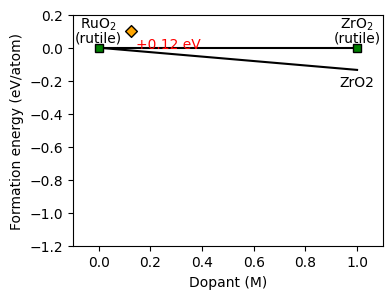

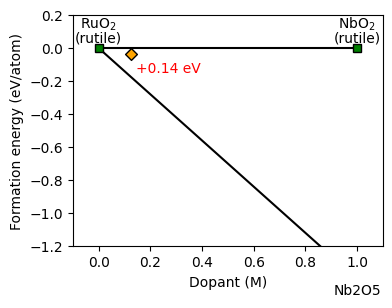

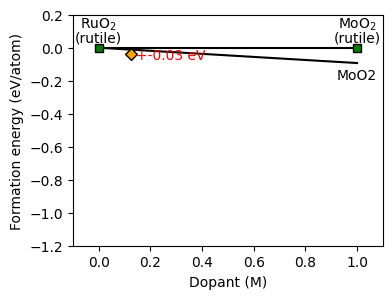

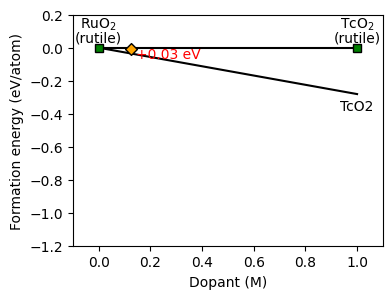

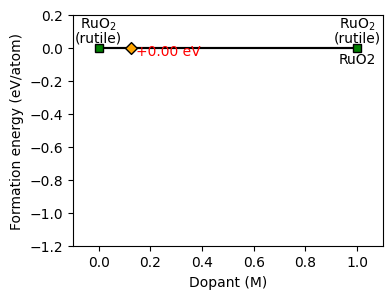

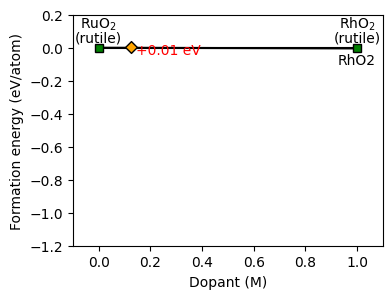

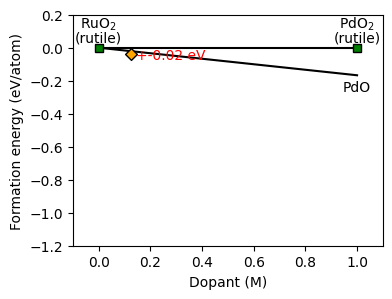

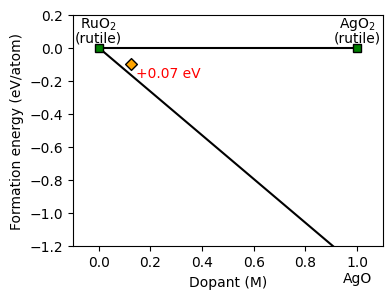

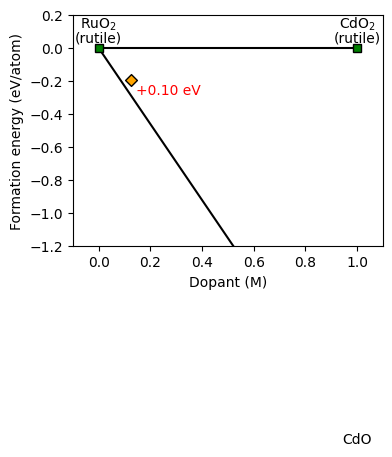

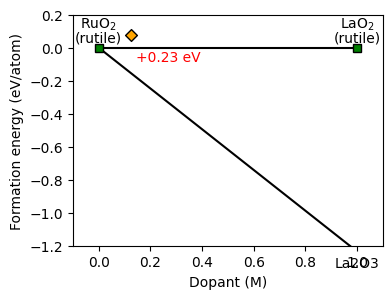

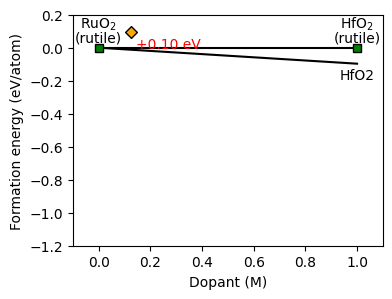

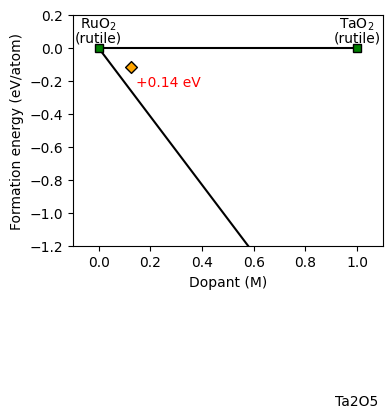

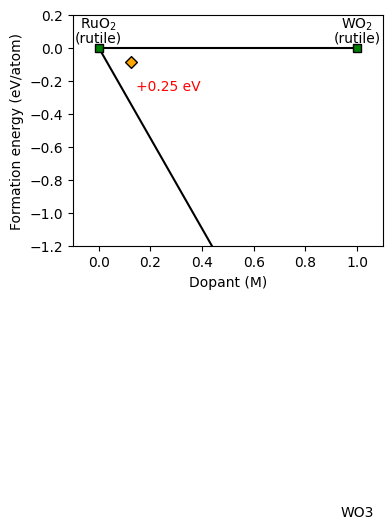

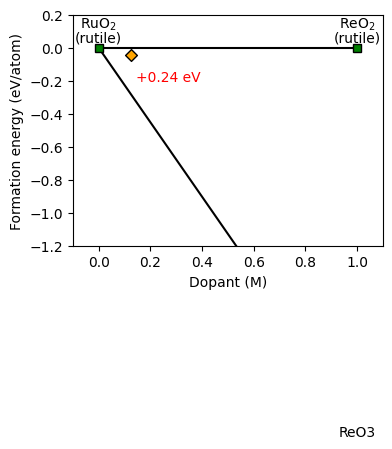

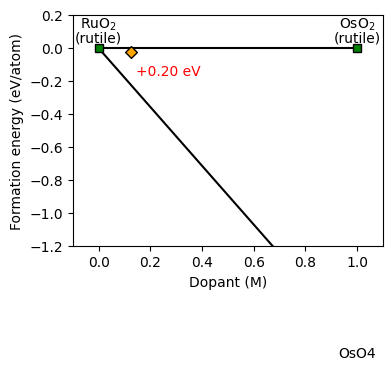

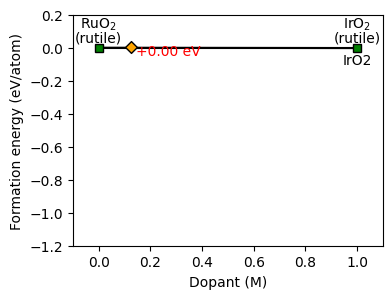

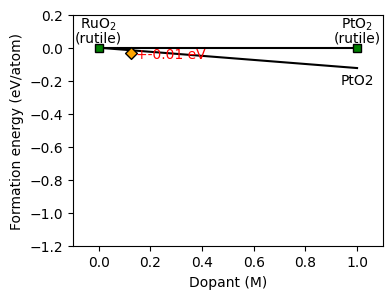

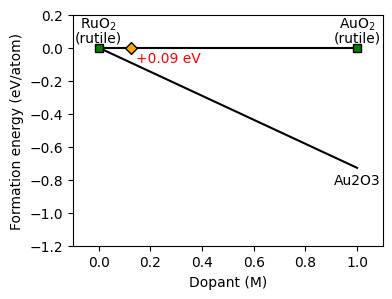

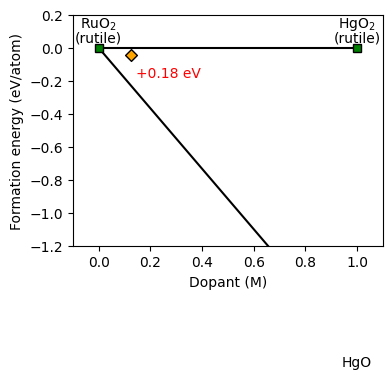

In [173]:

for i in element_indices:
    element = md.element(i).symbol
    m_ratio, o_ratio = int(data.loc[element, 'MxOy_x']), int(data.loc[element, 'MxOy_y'])
    if m_ratio == 1 and o_ratio == 1:
        formula = f'{element}O'
    elif m_ratio == 1:
        formula = f'{element}O{o_ratio}'
    else:
        formula = f'{element}{m_ratio}O{o_ratio}'
    
    plt.figure(figsize=(4,3))

    formation_energy_mxoy = 8*(data.loc[element, 'M-RuO2_de']-data.loc[element, 'M-RuO2_fe'])
    plt.plot([0.0, 1.0], [0.0, formation_energy_mxoy], color='black', linestyle='-', zorder=1)

    plt.plot([0.0, 1.0], [0.0, 0.0], color='black', marker='s', markeredgecolor='black', markerfacecolor='green', linestyle='-', zorder=1)
    plt.text(0.0, 0.02, 'RuO$_2$\n(rutile)', ha='center', va='bottom', linespacing=0.8)
    plt.text(1.0, 0.02, f'{element}O$_2$\n(rutile)', ha='center', va='bottom', linespacing=0.8)

    formation_energy_mruo2 = data.loc[element, 'M-RuO2_de']
    plt.scatter(1/8, formation_energy_mruo2, marker='D', edgecolor='black', facecolor='orange', zorder=2)
    plt.text(1/8+0.02, formation_energy_mxoy/16+formation_energy_mruo2/2-0.02, f'+{-formation_energy_mxoy/8+formation_energy_mruo2:.2f} eV', ha='left', va='center', color='red')
    plt.text(1.0, formation_energy_mxoy-0.03, f'{formula}', ha='center', va='top')

    plt.xlim(-0.1, 1.1)
    plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    plt.ylim(-1.2, 0.2)
    plt.xlabel('Dopant (M)')
    plt.ylabel('Formation energy (eV/atom)')
    plt.savefig(f'{root}/figures/bulk_convex_hull_{element}.png', dpi=dpi, transparent=True, bbox_inches='tight')
    plt.show()
    plt.close()
    